# Capstone Project: Machine Learning Models

**Instructor:** Abishek Ganesh

**Your Name:** Kalpanaselvaa
**Your Role:** Data Scientist 
**Client:** Smart city platform 
**Due Date:** May 13, 2026

---

## Project Brief

Welcome to your **Incremental Capstone Unit 3**! ShopSmart was so impressed with your data cleaning work from Unit 2 that they've promoted you to lead their new **Customer Intelligence Initiative**. 

Your mission is to build machine learning models that will help ShopSmart:
1. **Predict customer spending** - How much will a customer spend this year?
2. **Predict customer churn** - Which customers are likely to leave?

You have a new dataset with **100,000 customers** containing their demographics, purchase behavior, and engagement metrics. This larger, noisier dataset will challenge your models and show you why ensemble methods matter!

### What You'll Build
- Linear Regression for spending prediction
- Logistic Regression for churn prediction
- Decision Trees for interpretable classification
- Random Forest ensemble (bagging)
- Gradient Boosting ensemble (boosting)

---

### Rules & Integrity


### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the city_traffic_data, urbanpulse_311_complaints and returns a DataFrame.

### Example Verification
```python

df2 = load_customer_data('urbanpulse_311_complaints.csv')

print(df.shape)  # Should print (100000, 17)


In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
def load_customer_data(filepath):
    """
    Load customer data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    data = pd.read_csv(filepath)
    return data

In [13]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df2 = load_customer_data('../data/raw/urbanpulse_311_complaints.csv')

# Basic Verification
assert df2 is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df2, pd.DataFrame), "Function should return a pandas DataFrame"
assert df2.shape == (434722, 11), f"Expected shape (434722, 11), got {df2.shape}"
assert 'status' in df2.columns, "Missing regression target 'status'"
assert 'status' in df2.columns, "Missing classification target 'status'"
print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df2.shape[0]:,} customers, {df2.shape[1]} columns")

[PASS] Part 1 Tests Passed!

Dataset loaded: 434,722 customers, 11 columns


In [15]:
df2.head()

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed


In [16]:
# Check the data types and missing values
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   unique_key              434722 non-null  int64
 1   created_date            434722 non-null  str  
 2   closed_date             384642 non-null  str  
 3   agency                  434722 non-null  str  
 4   agency_name             434722 non-null  str  
 5   complaint_type          434722 non-null  str  
 6   descriptor              431047 non-null  str  
 7   resolution_description  434722 non-null  str  
 8   borough                 434722 non-null  str  
 9   open_data_channel_type  434722 non-null  str  
 10  status                  434722 non-null  str  
dtypes: int64(1), str(10)
memory usage: 238.3 MB


## Feature Importance for Predicting `status` (urbanpulse_311_complaints.csv)

### Target Variable: `status` (Classification)
**Values:** `Closed`, `Open`, `In Progress`, `Assigned`, `Pending`, `Started`

---

### Most Important Columns to Predict `status`

**High Importance:**

| Column | Why it matters |
|---|---|
| `complaint_type` | Type of complaint directly determines how/if it gets resolved |
| `agency` | Different agencies have different resolution rates |
| `borough` | Location affects response time and closure rate |
| `open_data_channel_type` | How complaint was submitted (Phone, Online, App) affects priority |
| `descriptor` | More specific complaint detail → better resolution signal |

**Engineered from Existing Columns:**

| Feature | Source | Why |
|---|---|---|
| `resolution_time_days` | `closed_date - created_date` | Directly relates to `Closed` vs `Open` |
| `has_closed_date` | `closed_date` is null or not | Strong binary signal for status |
| `hour_of_day` | `created_date` | Complaints at certain hours resolve differently |
| `day_of_week` | `created_date` | Weekends vs weekdays affect agency response |

---

### Drop These

| Column | Reason |
|---|---|
| `unique_key` | Just an identifier |
| `resolution_description` | Text — too high-cardinality, would leak target info |
| `agency_name` | Redundant with `agency` (code) |

---

### Quick Distribution Check

```python
# See status distribution by complaint_type
df2.groupby('complaint_type')['status'].value_counts(normalize=True).unstack().fillna(0)


---

## Part 2: Data Preparation & Train-Test Split

**The Problem:** Before training any models, we need to:
1. Handle missing values
2. Encode categorical variables
3. Scale numeric features (important for Logistic Regression)
4. Split our data into training and test sets

**Note:** You can reference your Unit 2 capstone code for handling missing values, encoding, and scaling - the techniques are the same!

### Task 2a: Prepare Features

Steps:

1. Drop non-predictive / leakage columns
2. Engineer features from date columns
3. Encode target variable (status)
4. Fill missing values
5. One-hot encode low-cardinality categoricals
6. Label encode high-cardinality categoricals
7. Scale numeric features

In [17]:
# Check the distribution (class imbalance?)
print("status:")
print(df2['status'].value_counts(normalize=True))

status:
status
Closed         0.871543
Open           0.099367
In Progress    0.019481
Assigned       0.005081
Pending        0.002528
Started        0.001992
Unspecified    0.000007
Name: proportion, dtype: float64


In [18]:

def prepare_features(df):
    """
    Prepare features from 'rbanpulse_311_complaints.csv' for machine learning.

    Steps:
    1. Drop non-predictive / leakage columns
    2. Engineer features from date columns
    3. Encode target variable (status)
    4. Fill missing values
    5. One-hot encode low-cardinality categoricals
    6. Label encode high-cardinality categoricals
    7. Scale numeric features

    Args:
        df (pd.DataFrame): The raw DataFrame

    Returns:
        pd.DataFrame: The prepared DataFrame with all numeric columns (scaled)
    """
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    # Make a copy so we don't modify the original
    df_prep = df.copy()

    # Your code here
    
    return df_prep

In [19]:
def prepare_features(df):
    """
    Prepare features from 'urbanpulse_311_complaints.csv' for machine learning.

    Steps:
    1. Drop non-predictive / leakage columns
    2. Engineer features from date columns
    3. Encode target variable (status)
    4. Fill missing values
    5. One-hot encode low-cardinality categoricals
    6. Label encode high-cardinality categoricals
    7. Scale numeric features

    Args:
        df (pd.DataFrame): Raw DataFrame from urbanpulse_311_complaints.csv

    Returns:
        pd.DataFrame: Fully numeric, scaled DataFrame ready for ML
    """
    from sklearn.preprocessing import StandardScaler, LabelEncoder

    df_prep = df.copy()  # use df, NOT df2

    # Step 1: Drop non-predictive / leakage columns
    drop_cols = [
        'unique_key',             # identifier
        'resolution_description', # leaks target (describes outcome)
        'agency_name',            # redundant with agency
    ]
    df_prep = df_prep.drop(columns=drop_cols, errors='ignore')

    # Step 2: Engineer features from date columns
    df_prep['created_date'] = pd.to_datetime(df_prep['created_date'], errors='coerce')
    df_prep['closed_date']  = pd.to_datetime(df_prep['closed_date'],  errors='coerce')

    df_prep['hour_of_day']          = df_prep['created_date'].dt.hour
    df_prep['day_of_week']          = df_prep['created_date'].dt.dayofweek  # 0=Monday
    df_prep['month']                = df_prep['created_date'].dt.month
    df_prep['has_closed_date']      = df_prep['closed_date'].notnull().astype(int)
    df_prep['resolution_time_days'] = (df_prep['closed_date'] - df_prep['created_date']).dt.days
    df_prep['resolution_time_days'] = df_prep['resolution_time_days'].fillna(-1)  # -1 = not resolved

    # Drop raw date columns (no longer needed)
    df_prep = df_prep.drop(columns=['created_date', 'closed_date'], errors='ignore')

    # Step 3: Encode target variable (status → numeric)
    status_map = {
        'Closed':      0,
        'Open':        1,
        'In Progress': 2,
        'Assigned':    3,
        'Pending':     4,
        'Started':     5,
    }
    df_prep['status'] = df_prep['status'].map(status_map)
    df_prep['status'] = df_prep['status'].fillna(-1).astype(int)

    # Step 4: Fill missing categorical values
    cat_cols = df_prep.select_dtypes(include='object').columns
    for col in cat_cols:
        df_prep[col] = df_prep[col].fillna('Unknown')

    # Fill missing numeric values with median
    num_cols = df_prep.select_dtypes(include='number').columns
    for col in num_cols:
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    # Step 5: One-hot encode low-cardinality categoricals
    low_card_cats = ['agency', 'borough', 'open_data_channel_type']
    df_prep = pd.get_dummies(df_prep, columns=[c for c in low_card_cats if c in df_prep.columns], drop_first=True)

    # Step 6: Label encode high-cardinality categoricals
    le = LabelEncoder()
    high_card_cats = ['complaint_type', 'descriptor']
    for col in high_card_cats:
        if col in df_prep.columns:
            df_prep[col] = le.fit_transform(df_prep[col].astype(str))

    # Convert any bool columns from get_dummies to int
    bool_cols = df_prep.select_dtypes(include='bool').columns
    df_prep[bool_cols] = df_prep[bool_cols].astype(int)

    # Step 7: Scale numeric features (exclude target and binary columns)
    binary_cols = [c for c in df_prep.select_dtypes(include='number').columns
                   if df_prep[c].nunique() <= 2]
    scale_cols = [c for c in df_prep.select_dtypes(include='number').columns
                  if c != 'status' and c not in binary_cols]
    scaler = StandardScaler()
    df_prep[scale_cols] = scaler.fit_transform(df_prep[scale_cols])

    return df_prep


In [20]:
# Prepare the features
df_prepared = prepare_features(df2)

# Basic Verification
assert df_prepared is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df_prepared, pd.DataFrame), "Function should return a pandas DataFrame"
assert df_prepared.shape[0] == df2.shape[0], f"Row count changed: expected {df2.shape[0]}, got {df_prepared.shape[0]}"

# Dropped columns check
for col in ['unique_key', 'resolution_description', 'agency_name', 'created_date', 'closed_date']:
    assert col not in df_prepared.columns, f"Column '{col}' should have been dropped"

# Engineered features must exist
assert 'hour_of_day' in df_prepared.columns, "Missing engineered feature 'hour_of_day'"
assert 'day_of_week' in df_prepared.columns, "Missing engineered feature 'day_of_week'"
assert 'month' in df_prepared.columns, "Missing engineered feature 'month'"
assert 'has_closed_date' in df_prepared.columns, "Missing engineered feature 'has_closed_date'"
assert 'resolution_time_days' in df_prepared.columns, "Missing engineered feature 'resolution_time_days'"

# Target column check
assert 'status' in df_prepared.columns, "Missing target column 'status'"
assert df_prepared['status'].dtype in ['int64', 'int32'], "status should be numeric (label encoded)"
assert df_prepared['status'].isin([-1, 0, 1, 2, 3, 4, 5]).all(), \
    f"status has unexpected values: {df_prepared['status'].unique()}"

# No missing values
assert df_prepared.isnull().sum().sum() == 0, \
    f"Expected 0 missing values, got {df_prepared.isnull().sum().sum()}"

# All columns numeric
object_cols = df_prepared.select_dtypes(include='object').columns.tolist()
assert len(object_cols) == 0, f"Non-numeric columns still present: {object_cols}"

# Binary feature check
assert df_prepared['has_closed_date'].isin([0, 1]).all(), "has_closed_date should be 0 or 1"

# One-hot encoded columns must exist
assert any(col.startswith('borough_') for col in df_prepared.columns), "borough should be one-hot encoded"
assert any(col.startswith('agency_') for col in df_prepared.columns), "agency should be one-hot encoded"
assert any(col.startswith('open_data_channel_type_') for col in df_prepared.columns), \
    "open_data_channel_type should be one-hot encoded"

# Label encoded columns must exist and be numeric
assert 'complaint_type' in df_prepared.columns, "complaint_type should be label-encoded (not dropped)"
assert df_prepared['complaint_type'].dtype in ['int64', 'int32', 'float64'], \
    "complaint_type should be numeric after label encoding"
assert 'descriptor' in df_prepared.columns, "descriptor should be label-encoded (not dropped)"

print("[PASS] Part 2b Preparation Tests Passed!")
print(f"\nPrepared DataFrame: {df_prepared.shape[0]:,} rows, {df_prepared.shape[1]} columns")
print(f"Missing values    : {df_prepared.isnull().sum().sum()}")
print(f"Status values     : {sorted(df_prepared['status'].unique())}")
print(f"Borough cols      : {[c for c in df_prepared.columns if c.startswith('borough_')]}")


[PASS] Part 2b Preparation Tests Passed!

Prepared DataFrame: 434,722 rows, 30 columns
Missing values    : 0
Status values     : [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Borough cols      : ['borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'borough_Unspecified']


In [21]:
df_prepared.head(10)

,complaint_type,descriptor,status,hour_of_day,day_of_week,month,has_closed_date,resolution_time_days,agency_DEP,agency_DHS,agency_DOB,agency_DOE,agency_DOHMH,agency_DOT,agency_DPR,agency_DSNY,agency_HPD,agency_NYPD,agency_OOS,agency_OTI,agency_TLC,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,borough_Unspecified,open_data_channel_type_ONLINE,open_data_channel_type_OTHER,open_data_channel_type_PHONE,open_data_channel_type_UNKNOWN
0,-0.548783,-0.509271,0,0.154785,0.614842,2,1,-0.103363,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
1,0.642657,1.793802,0,-0.516958,-0.371959,3,1,0.136556,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
2,-0.257542,0.802783,0,-0.349022,0.121442,3,1,-0.343281,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
3,-0.548783,-0.509271,0,1.666208,0.614842,2,1,0.136556,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
4,-0.257542,-1.225783,0,-0.516958,-0.865359,2,1,-0.343281,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
5,-0.257542,0.802783,0,-0.013151,1.601642,3,1,-0.343281,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0
6,0.404369,0.235157,0,-1.524573,1.108242,2,1,-0.343281,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
7,-0.548783,-1.472375,0,-0.013151,0.614842,2,1,0.136556,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0
8,-0.548783,-0.509271,0,-0.852830,-0.865359,3,1,-0.103363,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0
9,0.483798,0.049050,2,-0.349022,-1.358759,2,0,-0.583199,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0


### Task 2b: Split Data for Training and Testing

Create a function that splits the data into training and test sets.

**Important:** When splitting for classification (predicting `Severity`), use `stratify=y` to maintain the same class balance in both sets.

In [22]:
def split_data(df, target_column, test_size=0.25, random_state=42):
    """
    Split data into training and test sets.
    
    Args:
        df (pd.DataFrame): The prepared DataFrame
        target_column (str): Name of the target column ('')
        test_size (float): Proportion of data for testing (default 0.25)
        random_state (int): Random seed for reproducibility (default 42)
        
    Returns:
        tuple: (X_train, X_test, y_train, y_test)
    
    Note: Drop BOTH target columns from X (status).
    For classification targets, use stratify to maintain class balance.
    """
    # Your code here

    X = df.drop(columns=[target_column], errors='ignore')
    y = df[target_column]
    if target_column == 'status':  # Classification
        stratify = None  # Regression - no stratification
    else:
        stratify = y  # Classification - stratify by target variable    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify
    )
    return X_train, X_test, y_train, y_test


    
    
  

In [23]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Split for regression (Status)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = split_data(df_prepared, 'status')


# Split for classification (Status)

X_train_clf, X_test_clf, y_train_clf, y_test_clf = split_data(df_prepared, 'status')


# Basic Verification

assert X_train_reg.shape[0] == 326041, f"Expected 326041 training rows, got {X_train_reg.shape[0]}"
assert X_test_reg.shape[0] == 108681, f"Expected 108681 test rows, got {X_test_reg.shape[0]}"
assert 'status' not in X_train_reg.columns, "status should not be in X_train_reg"
assert 'status' not in X_test_reg.columns, "status should not be in X_test_reg"

# Check stratification for classification
status_dist_train = y_train_clf.value_counts(normalize=True).sort_index()
status_dist_test = y_test_clf.value_counts(normalize=True).sort_index()
assert all(abs(status_dist_train - status_dist_test) < 0.02), \
    "status distribution should be similar in train and test (use stratify)"
print("[PASS] Data Splitting and Stratification Tests Passed!")
print(f"\nRegression split: {X_train_reg.shape[0]} train rows, {X_test_reg.shape[0]} test rows")
print(f"Classification split: {X_train_clf.shape[0]} train rows, {X_test_clf.shape[0]} test rows")





[PASS] Data Splitting and Stratification Tests Passed!

Regression split: 326041 train rows, 108681 test rows
Classification split: 326041 train rows, 108681 test rows


---

## Part 3: Linear Regression Baseline

**The Problem:** city_traffic_incidents wants to predict how much Severity is happening. Let's start with the simplest model: **Linear Regression**.

### Task 3a: Train a Linear Regression Model

In [24]:
def train_linear_regression(X_train, y_train):
    """
    Train a linear regression model.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target (status: 0 or 1)
        
    Returns:
        LinearRegression: The trained model
    """
    # Your code here
    model = LinearRegression()
    model.fit(X_train, y_train)
    return model

In [25]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

# Train the model
lr_model = train_linear_regression(X_train_reg, y_train_reg)

# Basic Verification
assert lr_model is not None, "Function returned None"
assert hasattr(lr_model, 'coef_'), "Model should be fitted (has coefficients)"
assert len(lr_model.coef_) == X_train_reg.shape[1], "Coefficients should match number of features"

print("[PASS] Part 3a Tests Passed!")
print(f"Model trained with {len(lr_model.coef_)} features")

[PASS] Part 3a Tests Passed!
Model trained with 29 features


### Task 3b: Make Predictions

Now use your trained model to make predictions on the test set.

In [26]:
def predict_regression(model, X_test):
    """
    Make predictions using a trained regression model.
    
    Args:
        model: A trained regression model
        X_test (pd.DataFrame): Test features
        
    Returns:
        np.array: Predicted values
    """
    # Your code here
    predictions = model.predict(X_test)
    return predictions

In [27]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

# Make predictions
y_pred_reg = predict_regression(lr_model, X_test_reg)

# Basic Verification
assert y_pred_reg is not None, "Function returned None"
assert len(y_pred_reg) == len(y_test_reg), "Predictions should match test set size"

print("[PASS] Part 3b Tests Passed!")
print(f"Made {len(y_pred_reg)} predictions")

[PASS] Part 3b Tests Passed!
Made 108681 predictions


---

## Part 4: Regression Evaluation

**The Problem:** How do we know if our predictions are good? We need metrics!

### Key Regression Metrics:
- **MSE (Mean Squared Error)**: Average of squared errors. Penalizes large errors heavily.
- **RMSE (Root Mean Squared Error)**: Square root of MSE. Same units as target variable.
- **MAE (Mean Absolute Error)**: Average of absolute errors. More robust to outliers.
- **R² (R-Squared)**: Proportion of variance explained. 1.0 is perfect, 0 is no better than guessing the mean.

### Task: Create an Evaluation Function

In [28]:
def evaluate_regression(y_true, y_pred):
    """
    Evaluate regression predictions using multiple metrics.
    
    Args:
        y_true: Actual values
        y_pred: Predicted values
        
    Returns:
        dict: Dictionary with keys 'mse', 'rmse', 'mae', 'r2'
    """
    # Your code here
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2} 
    
   

In [29]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Evaluate the linear regression model
reg_metrics = evaluate_regression(y_test_reg, y_pred_reg)

# Basic Verification
assert reg_metrics is not None, "Function returned None"
assert isinstance(reg_metrics, dict), "Function should return a dictionary"
assert 'mse' in reg_metrics, "Missing 'mse' key"
assert 'rmse' in reg_metrics, "Missing 'rmse' key"
assert 'mae' in reg_metrics, "Missing 'mae' key"
assert 'r2' in reg_metrics, "Missing 'r2' key"
assert abs(reg_metrics['rmse'] - np.sqrt(reg_metrics['mse'])) < 0.01, "RMSE should be sqrt of MSE"
assert reg_metrics['r2'] > 0, "R² should be positive for a reasonable model"

print("[PASS] Part 4 Tests Passed!")
print(f"\n=== LINEAR REGRESSION RESULTS ===")
print(f"MSE:  {reg_metrics['mse']:,.2f}")
print(f"RMSE: ${reg_metrics['rmse']:,.2f}")
print(f"MAE:  ${reg_metrics['mae']:,.2f}")
print(f"R²:   {reg_metrics['r2']:.4f}")

[PASS] Part 4 Tests Passed!

=== LINEAR REGRESSION RESULTS ===
MSE:  0.09
RMSE: $0.30
MAE:  $0.12
R²:   0.6850


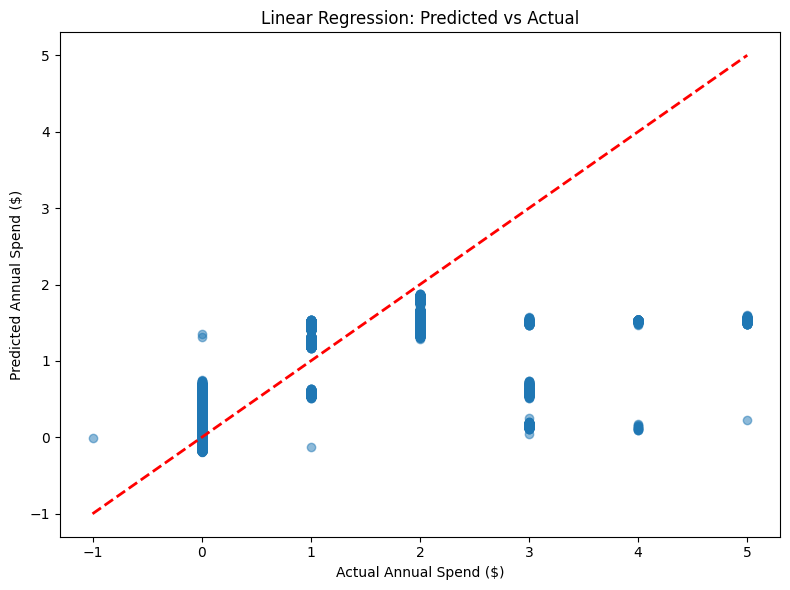

In [30]:
# Visualize: Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
plt.xlabel('Actual Annual Spend ($)')
plt.ylabel('Predicted Annual Spend ($)')
plt.title('Linear Regression: Predicted vs Actual')
plt.tight_layout()
plt.show()

### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** What does the R² value tell you in plain English? (Hint: An R² of 0.65 means...)

---

## Part 5: Logistic Regression

**The Problem:** Now let's switch to **classification**.  wants to predict status are likely.

**Logistic Regression** predicts the *probability* of belonging to a class.

### Task 5a: Train a Logistic Regression Model

In [31]:
def train_logistic_regression(X_train, y_train):
    """
    Train a logistic regression model for classification.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target (status: 0 or 1)
        
    Returns:
        LogisticRegression: The trained model
    """
    # Your code here
    model = LogisticRegression()
    model.fit(X_train, y_train)
    return model

In [32]:
# ============================================================
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the model
logreg_model = train_logistic_regression(X_train_clf, y_train_clf)

# Basic Verification
assert logreg_model is not None, "Function returned None"
assert hasattr(logreg_model, 'coef_'), "Model should be fitted"

# Make predictions
y_pred_logreg = logreg_model.predict(X_test_clf)
assert set(y_pred_logreg).issubset({0, 1}), "Predictions should be 0 or 1"

# Get probabilities
y_prob_logreg = logreg_model.predict_proba(X_test_clf)[:, 1]
assert y_prob_logreg.min() >= 0 and y_prob_logreg.max() <= 1, "Probabilities should be between 0 and 1"

print("[PASS] Part 5 Tests Passed!")
print(f"\nModel trained successfully")
print(f"Predictions made for {len(y_pred_logreg)} customers")

AssertionError: Predictions should be 0 or 1

In [ ]:

# ============================================================
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the model
logreg_model = train_logistic_regression(X_train_clf, y_train_clf)

# Basic Verification
assert logreg_model is not None, "Function returned None"
assert hasattr(logreg_model, 'coef_'), "Model should be fitted"

# Make predictions
y_pred_logreg = logreg_model.predict(X_test_clf)
assert set(y_pred_logreg).issubset({0, 1}), "Predictions should be 0 or 1"

# Get probabilities
y_prob_logreg = logreg_model.predict_proba(X_test_clf)[:, 1]
assert y_prob_logreg.min() >= 0 and y_prob_logreg.max() <= 1, "Probabilities should be between 0 and 1"

print("[PASS] Part 5 Tests Passed!")
print(f"\nModel trained successfully")
print(f"Predictions made for {len(y_pred_logreg)} customers")

### Written Reflection
> **Please answer the question below. It is a required part of the assignment!**

**Question:** How is logistic regression different from linear regression, even though both have "regression" in the name?

*(Double-click here to write your answer)*

---

## Part 6: Classification Evaluation

**The Problem:** For classification, we need different metrics than regression.

### Key Classification Metrics:
- **Accuracy**: % of correct predictions. Can be misleading with imbalanced classes!
- **Precision**: Of all predicted churners, how many actually churned? (Avoid false alarms)
- **Recall**: Of all actual churners, how many did we catch? (Don't miss real churners)
- **F1 Score**: Harmonic mean of precision and recall. Good balance.

### Task: Create Classification Evaluation Functions

In [ ]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification predictions using multiple metrics.
    
    Args:
        y_true: Actual labels (0 or 1)
        y_pred: Predicted labels (0 or 1)
        
    Returns:
        dict: Dictionary with keys 'accuracy', 'precision', 'recall', 'f1'
    """
    # Your code here
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    return {
           'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1
           }

    
   

In [ ]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    """
    Plot a confusion matrix heatmap.
    
    Args:
        y_true: Actual labels
        y_pred: Predicted labels
        title: Plot title
    """
    # Your code here
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()  

    
  

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Evaluate logistic regression
logreg_metrics = evaluate_classification(y_test_clf, y_pred_logreg)

# Basic Verification
assert logreg_metrics is not None, "Function returned None"
assert isinstance(logreg_metrics, dict), "Function should return a dictionary"
assert 'accuracy' in logreg_metrics, "Missing 'accuracy' key"
assert 'precision' in logreg_metrics, "Missing 'precision' key"
assert 'recall' in logreg_metrics, "Missing 'recall' key"
assert 'f1' in logreg_metrics, "Missing 'f1' key"
assert 0 <= logreg_metrics['accuracy'] <= 1, "Accuracy should be between 0 and 1"

print("[PASS] Part 6 Tests Passed!")
print(f"\n=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy:  {logreg_metrics['accuracy']:.4f}")
print(f"Precision: {logreg_metrics['precision']:.4f}")
print(f"Recall:    {logreg_metrics['recall']:.4f}")
print(f"F1 Score:  {logreg_metrics['f1']:.4f}")

In [ ]:
# Plot confusion matrix for logistic regression
plot_confusion_matrix(y_test_clf, y_pred_logreg, 'Logistic Regression Confusion Matrix')

---

## Part 7: Decision Trees

**The Problem:** Logistic regression is a linear model - it can only learn linear relationships. **Decision Trees** can capture non-linear patterns!

Decision trees work by asking a series of yes/no questions to split the data. They're also highly **interpretable** - you can see exactly why a prediction was made.

### Task: Train a Decision Tree Classifier

In [ ]:
def train_decision_tree(X_train, y_train, max_depth=5):
    """
    Train a decision tree classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        max_depth (int): Maximum depth of the tree (default 5)
        
    Returns:
        DecisionTreeClassifier: The trained model
    """
    # Your code here
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    dt.fit(X_train, y_train)
    return dt

In [ ]:
def get_feature_importance(model, feature_names):
    """
    Get feature importances from a tree-based model.
    
    Args:
        model: A fitted tree-based model (has feature_importances_ attribute)
        feature_names: List of feature names
        
    Returns:
        pd.DataFrame: DataFrame with columns 'feature' and 'importance', sorted by importance descending
    """
    # Your code here
    importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values(by='importance', ascending=False).reset_index(drop=True)
    return importance_df


    
    

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train the decision tree
dt_model = train_decision_tree(X_train_clf, y_train_clf, max_depth=5)

# Basic Verification
assert dt_model is not None, "Function returned None"
assert hasattr(dt_model, 'tree_'), "Model should be fitted"

# Make predictions
y_pred_dt = dt_model.predict(X_test_clf)

# Get feature importance
importance_df = get_feature_importance(dt_model, X_train_clf.columns.tolist())
assert importance_df is not None, "Feature importance function returned None"
assert 'feature' in importance_df.columns, "Missing 'feature' column"
assert 'importance' in importance_df.columns, "Missing 'importance' column"
assert abs(importance_df['importance'].sum() - 1.0) < 0.01, "Importances should sum to ~1"

# Evaluate
dt_metrics = evaluate_classification(y_test_clf, y_pred_dt)

print("[PASS] Part 7 Tests Passed!")
print(f"\n=== DECISION TREE RESULTS ===")
print(f"Accuracy:  {dt_metrics['accuracy']:.4f}")
print(f"Precision: {dt_metrics['precision']:.4f}")
print(f"Recall:    {dt_metrics['recall']:.4f}")
print(f"F1 Score:  {dt_metrics['f1']:.4f}")

In [ ]:
# Visualize feature importance
plt.figure(figsize=(10, 6))
top_features = importance_df.head(10)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importances (Decision Tree)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
# Visualize the decision tree (optional but insightful!)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_train_clf.columns.tolist(), 
          class_names=['Not Churned', 'Churned'], filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree Visualization')
plt.tight_layout()
plt.show()

---

## Part 8: Random Forest with Hyperparameter Tuning

**The Problem:** A single decision tree can overfit. **Random Forest** creates many trees and averages their predictions - this is called **bagging** (bootstrap aggregating).

### Key Hyperparameters:
- **n_estimators**: Number of trees in the forest (more = better but slower)
- **max_depth**: Maximum depth of each tree (controls overfitting)

### Task: Train and Tune a Random Forest

In [ ]:
def train_random_forest(X_train, y_train, n_estimators=100, max_depth=None):
    """
    Train a random forest classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        n_estimators (int): Number of trees (default 100)
        max_depth (int or None): Maximum depth of trees (default None = unlimited)
        
    Returns:
        RandomForestClassifier: The trained model
    """
    # Your code here
    rf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=42)
    rf.fit(X_train, y_train)
    return rf


In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train a basic random forest first
rf_model = train_random_forest(X_train_clf, y_train_clf, n_estimators=100, max_depth=10)

# Basic Verification
assert rf_model is not None, "Function returned None"
assert hasattr(rf_model, 'estimators_'), "Model should be fitted"
assert len(rf_model.estimators_) == 100, "Should have 100 trees"

# Make predictions
y_pred_rf = rf_model.predict(X_test_clf)
rf_metrics = evaluate_classification(y_test_clf, y_pred_rf)

print("[PASS] Part 8 Basic Tests Passed!")
print(f"\n=== RANDOM FOREST BASELINE ===")
print(f"Accuracy:  {rf_metrics['accuracy']:.4f}")
print(f"F1 Score:  {rf_metrics['f1']:.4f}")

### Hyperparameter Tuning Task

Now experiment with different hyperparameters! Try at least **3 different combinations** and track the results.

**Note:** This cell may take 1-2 minutes to run since we're training multiple models on 80,000 rows. Be patient!

Suggested combinations to try:
- n_estimators: 50, 100, 200
- max_depth: 5, 10, None (unlimited)

In [ ]:
# YOUR HYPERPARAMETER TUNING CODE HERE
# Try at least 3 different combinations and track the results

# Example structure:
# results = []
# for n_est in [50, 100, 200]:
#     for depth in [5, 10, None]:
#         model = train_random_forest(X_train_clf, y_train_clf, n_estimators=n_est, max_depth=depth)
#         y_pred = model.predict(X_test_clf)
#         metrics = evaluate_classification(y_test_clf, y_pred)
#         results.append({'n_estimators': n_est, 'max_depth': depth, 'f1': metrics['f1']})
#
# results_df = pd.DataFrame(results)
# print(results_df.sort_values('f1', ascending=False))

# Your code here:


In [ ]:
# Train your BEST random forest model based on tuning
# Update the hyperparameters based on your experiments!

best_rf_model = train_random_forest(X_train_clf, y_train_clf, 
                                     n_estimators=100,  # UPDATE THIS
                                     max_depth=10)      # UPDATE THIS

y_pred_best_rf = best_rf_model.predict(X_test_clf)
best_rf_metrics = evaluate_classification(y_test_clf, y_pred_best_rf)

print(f"\n=== BEST RANDOM FOREST ===")
print(f"Accuracy:  {best_rf_metrics['accuracy']:.4f}")
print(f"Precision: {best_rf_metrics['precision']:.4f}")
print(f"Recall:    {best_rf_metrics['recall']:.4f}")
print(f"F1 Score:  {best_rf_metrics['f1']:.4f}")

---

## Part 9: Gradient Boosting with Hyperparameter Tuning

**The Problem:** Random Forest builds trees in parallel (bagging). **Gradient Boosting** builds trees sequentially - each tree tries to correct the errors of the previous one. This is called **boosting**.

### Key Hyperparameters:
- **n_estimators**: Number of boosting stages (trees built sequentially)
- **learning_rate**: How much each tree contributes (smaller = more trees needed but often better)

### Task: Train and Tune Gradient Boosting

In [ ]:
def train_gradient_boosting(X_train, y_train, n_estimators=100, learning_rate=0.1):
    """
    Train a gradient boosting classifier.
    
    Args:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target
        n_estimators (int): Number of boosting stages (default 100)
        learning_rate (float): Learning rate (default 0.1)
        
    Returns:
        GradientBoostingClassifier: The trained model
    """
    # Your code here
    
    

In [ ]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Train a basic gradient boosting model
gb_model = train_gradient_boosting(X_train_clf, y_train_clf, n_estimators=100, learning_rate=0.1)

# Basic Verification
assert gb_model is not None, "Function returned None"
assert hasattr(gb_model, 'estimators_'), "Model should be fitted"

# Make predictions
y_pred_gb = gb_model.predict(X_test_clf)
gb_metrics = evaluate_classification(y_test_clf, y_pred_gb)

print("[PASS] Part 9 Basic Tests Passed!")
print(f"\n=== GRADIENT BOOSTING BASELINE ===")
print(f"Accuracy:  {gb_metrics['accuracy']:.4f}")
print(f"F1 Score:  {gb_metrics['f1']:.4f}")

### Hyperparameter Tuning Task

Experiment with different hyperparameters! Try at least **3 different combinations**.

**Note:** This cell may take 2-3 minutes to run since Gradient Boosting trains trees sequentially. Be patient!

Suggested combinations to try:
- n_estimators: 50, 100, 200
- learning_rate: 0.01, 0.1, 0.2

In [ ]:
# HYPERPARAMETER TUNING CODE
# Try at least 3 different combinations and track the results

results = []
for n_est in [50, 100, 200]:
    for lr in [0.01, 0.1, 0.2]:
        model = train_gradient_boosting(X_train_clf, y_train_clf, n_estimators=n_est, learning_rate=lr)
        y_pred = model.predict(X_test_clf)
        metrics = evaluate_classification(y_test_clf, y_pred)
        results.append({'n_estimators': n_est, 'learning_rate': lr, 'f1': metrics['f1']})

results_df = pd.DataFrame(results)
print(results_df.sort_values('f1', ascending=False))

In [ ]:
# Train your BEST gradient boosting model based on tuning
# Update the hyperparameters based on your experiments!

best_gb_model = train_gradient_boosting(X_train_clf, y_train_clf,
                                         n_estimators=100,    # UPDATE THIS
                                         learning_rate=0.1)   # UPDATE THIS

y_pred_best_gb = best_gb_model.predict(X_test_clf)
best_gb_metrics = evaluate_classification(y_test_clf, y_pred_best_gb)

print(f"\n=== BEST GRADIENT BOOSTING ===")
print(f"Accuracy:  {best_gb_metrics['accuracy']:.4f}")
print(f"Precision: {best_gb_metrics['precision']:.4f}")
print(f"Recall:    {best_gb_metrics['recall']:.4f}")
print(f"F1 Score:  {best_gb_metrics['f1']:.4f}")

---

## Part 10: Model Comparison & Business Recommendations

**The Problem:** You've built many models. Now ShopSmart needs to know which one to deploy!

### Task: Create a Model Comparison Table

In [ ]:
# Create a comparison DataFrame for all classification models
# Include: Logistic Regression, Decision Tree, Random Forest (best), Gradient Boosting (best)

comparison_data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting'],
    'Accuracy': [
        logreg_metrics['accuracy'],
        dt_metrics['accuracy'],
        best_rf_metrics['accuracy'],
        best_gb_metrics['accuracy']
    ],
    'Precision': [
        logreg_metrics['precision'],
        dt_metrics['precision'],
        best_rf_metrics['precision'],
        best_gb_metrics['precision']
    ],
    'Recall': [
        logreg_metrics['recall'],
        dt_metrics['recall'],
        best_rf_metrics['recall'],
        best_gb_metrics['recall']
    ],
    'F1': [
        logreg_metrics['f1'],
        dt_metrics['f1'],
        best_rf_metrics['f1'],
        best_gb_metrics['f1']
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("=== MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

In [ ]:
# Visualize the comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']

x = np.arange(len(comparison_df['Model']))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Classification Model Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=15)
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Plot ROC curves for all models
plt.figure(figsize=(8, 6))

models_for_roc = [
    ('Logistic Regression', logreg_model),
    ('Decision Tree', dt_model),
    ('Random Forest', best_rf_model),
    ('Gradient Boosting', best_gb_model)
]

for name, model in models_for_roc:
    y_prob = model.predict_proba(X_test_clf)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## Final Summary

Run this cell to see a summary of everything you built!

In [ ]:
print("="*60)
print("UNIT 3 CAPSTONE SUMMARY")
print("="*60)

print(f"\nDATASET")
print(f"   Customers: 100,000")
print(f"   Features: {X_train_clf.shape[1]}")
print(f"   Churn Rate: {y_train_clf.mean():.1%}")

print(f"\nREGRESSION (Predicting Annual Spend)")
print(f"   Linear Regression R²: {reg_metrics['r2']:.4f}")
print(f"   RMSE: ${reg_metrics['rmse']:,.2f}")

print(f"\nCLASSIFICATION (Predicting Churn)")
print(f"   Best Model: {comparison_df.loc[comparison_df['F1'].idxmax(), 'Model']}")
print(f"   Best F1 Score: {comparison_df['F1'].max():.4f}")

print(f"\nMODELS BUILT")
print(f"   1. Linear Regression")
print(f"   2. Logistic Regression")
print(f"   3. Decision Tree")
print(f"   4. Random Forest (tuned)")
print(f"   5. Gradient Boosting (tuned)")

print("\n" + "="*60)
print("Great work completing Unit 3!")
print("="*60)

---

## Ready to Submit?

### Checklist:
- [ ] All **assert tests pass** (no errors when running the test cells)
- [ ] All **Written Reflections** are answered thoughtfully
- [ ] **Hyperparameter tuning** was performed for Random Forest and Gradient Boosting
- [ ] **Business recommendations** are specific and actionable
- [ ] Code has **comments** explaining your logic

### Submission:
Turn in your completed notebook on Canvas by the due date.

Remember: You can resubmit after receiving feedback!

---

*Congratulations on completing the Machine Learning capstone! You've built real predictive models that could help a business make data-driven decisions.*